# Week 1: 알고리즘 도메인 ReAct Agent

코딩 테스트 준비 도메인 — *개념 정리, 프로그래머스 문제 추천, 풀이 리뷰* 세 가지 use case를 도구 3개에 1:1 매핑

| 도구 | 용도 |
|---|---|
| `get_algorithm_pattern(name)` | 패턴 설명/시간복잡도/템플릿 |
| `recommend_problems(topic, level, problem_id)` | 프로그래머스 문제 추천/조회 |
| `review_solution(problem_id, user_code)` | 풀이 리뷰용 reference rubric |

## 그래프
```mermaid
flowchart TD
    START([START]) --> agent
    agent -->|tool_calls 있음| tools[tools<br/>ToolNode]
    agent -->|tool_calls 없음<br/>tools_condition: END → remap| format_answer[format_answer<br/>with_structured_output]
    tools --> agent
    format_answer --> END([END])
```
- `agent` — `bind_tools`된 LLM. 도구 호출 여부 결정
- `tools` — `langgraph.prebuilt.ToolNode` (강의 06번 패턴)
- 분기 — `langgraph.prebuilt.tools_condition` 의 `END` 출구를 `format_answer`로 remap
- `format_answer` — `with_structured_output(ReActAnswer)`로 최종 응답 정규화

## 환경 설정

In [1]:
from dotenv import load_dotenv, find_dotenv
import os

load_dotenv(find_dotenv(), override=True)
os.environ.setdefault("LANGSMITH_PROJECT", "week1-algorithm-react")
os.environ["LANGSMITH_TRACING_V2"] = "false"

print("OPENAI_API_KEY set:    ", bool(os.getenv("OPENAI_API_KEY")))
print("ANTHROPIC_API_KEY set: ", bool(os.getenv("ANTHROPIC_API_KEY")))

OPENAI_API_KEY set:     True
ANTHROPIC_API_KEY set:  False


## Mock 데이터 (프로그래머스 문제 6개)

`PROBLEMS` 의 각 문제에는 `reference_approach` / `reference_complexity` / `key_checkpoints` / `common_pitfalls` 가 박혀 있고, 이게 `review_solution` 의 rubric 소스가 된다.

In [2]:
PROBLEMS: dict[str, dict] = {
    "pgs-43238": {
        "id": "pgs-43238",
        "title": "입국심사",
        "platform": "Programmers",
        "level": "Lv.3",
        "topics": ["binary-search"],
        "url": "https://school.programmers.co.kr/learn/courses/30/lessons/43238",
        "description": (
            "n명과 각 입국 심사대 처리 시간 times[]가 주어질 때, 모두 심사하기 위한 최소 시간을 구하는 문제. "
            "답이 시간 t에 대해 단조 → parametric binary search."
        ),
        "reference_approach": (
            "f(t) = sum(t // x for x in times)는 t에 대해 단조 증가. f(t) >= n 인 최소 t를 이분 탐색."
        ),
        "reference_complexity": "O(M log(max(times) * n)), M = len(times)",
        "key_checkpoints": [
            "lo=1, hi=max(times)*n 으로 범위를 충분히 크게",
            "단조성을 명시 (시간↑ → 처리 인원↑)",
            "f(mid) >= n 일 때 hi=mid-1 (lower bound)",
        ],
        "common_pitfalls": [
            "lo=0 이면 무한 루프",
            "hi=max(times) 만 두면 사람 수 많을 때 답 못 찾음",
            "O(N) 선형 탐색은 N=10^9 스케일에서 TLE",
        ],
    },
    "pgs-43236": {
        "id": "pgs-43236",
        "title": "징검다리",
        "platform": "Programmers",
        "level": "Lv.4",
        "topics": ["binary-search"],
        "url": "https://school.programmers.co.kr/learn/courses/30/lessons/43236",
        "description": "바위 좌표가 주어지고 n개를 제거할 수 있을 때 가장 짧은 점프 거리의 최댓값. parametric search.",
        "reference_approach": "최소 점프 거리 d 이분 탐색. f(d) = 거리 d 미만이 되는 인접 쌍을 그리디 제거 횟수.",
        "reference_complexity": "O(R log(distance)), R = len(rocks)",
        "key_checkpoints": [
            "바위 정렬",
            "제거 시뮬레이션을 그리디로 (마지막 위치 추적)",
            "upper bound 형태 — 답=lo-1 또는 hi 처리",
        ],
        "common_pitfalls": [
            "distance 배열을 정렬하는 잘못된 접근 (단조성 깨짐)",
            "d 범위를 좌표값이 아닌 인덱스로 잡음",
        ],
    },
    "pgs-43165": {
        "id": "pgs-43165",
        "title": "타겟 넘버",
        "platform": "Programmers",
        "level": "Lv.2",
        "topics": ["bfs-dfs"],
        "url": "https://school.programmers.co.kr/learn/courses/30/lessons/43165",
        "description": "각 원소 앞에 +/-를 붙여 target을 만드는 경우의 수. DFS/백트래킹 입문.",
        "reference_approach": "각 i에서 +/- 이진 분기 DFS. i==len 도달 시 누적합==target 검사.",
        "reference_complexity": "O(2^N)",
        "key_checkpoints": [
            "base case (i == len(numbers))",
            "+ 와 - 두 분기 모두 호출",
            "DP 메모이제이션 ((i, sum)) 도 가능",
        ],
        "common_pitfalls": [
            "DFS를 BFS로 짜며 메모리 폭발",
            "누적합을 list append/pop 부수효과로",
        ],
    },
    "pgs-118667": {
        "id": "pgs-118667",
        "title": "두 큐 합 같게 만들기",
        "platform": "Programmers",
        "level": "Lv.2",
        "topics": ["two-pointers", "queue"],
        "url": "https://school.programmers.co.kr/learn/courses/30/lessons/118667",
        "description": "두 큐 합을 같게 만드는 최소 작업 횟수. pop/insert를 두 포인터처럼.",
        "reference_approach": "deque 1개로 합쳐 보고 합이 큰 쪽에서 pop → 작은 쪽에 push. 종료 상한 4*N.",
        "reference_complexity": "O(N)",
        "key_checkpoints": [
            "전체 합 홀수면 -1",
            "두 합을 O(1) 로 갱신 (재계산 X)",
            "4*N 초과 시 -1",
        ],
        "common_pitfalls": [
            "매 step sum() 호출로 O(N^2) → TLE",
            "list pop(0) 으로 O(N^2)",
            "종료 조건 누락",
        ],
    },
    "pgs-67258": {
        "id": "pgs-67258",
        "title": "보석 쇼핑",
        "platform": "Programmers",
        "level": "Lv.3",
        "topics": ["sliding-window", "hash-map"],
        "url": "https://school.programmers.co.kr/learn/courses/30/lessons/67258",
        "description": "모든 종류의 보석을 포함하는 가장 짧은 연속 구간. 가변 슬라이딩 윈도우.",
        "reference_approach": "left/right 두 포인터로 윈도우 늘리며 dict 카운트 갱신, 모든 종류 포함되면 left 줄여 최소화.",
        "reference_complexity": "O(N)",
        "key_checkpoints": [
            "전체 보석 종류 수 미리 계산 (set)",
            "left 이동 시 dict 카운트 0이면 키 삭제",
            "답 [s+1, e+1] 1-index 반환",
        ],
        "common_pitfalls": [
            "left 이동을 if가 아닌 while로 좁혀야 최소 윈도우",
        ],
    },
    "pgs-42898": {
        "id": "pgs-42898",
        "title": "등굣길",
        "platform": "Programmers",
        "level": "Lv.3",
        "topics": ["dp"],
        "url": "https://school.programmers.co.kr/learn/courses/30/lessons/42898",
        "description": "M x N 격자에서 (1,1)→(M,N) 오른쪽/아래만 이동, 물웅덩이 피해 가는 경로 수 (mod 1e9+7).",
        "reference_approach": "dp[r][c] = dp[r-1][c] + dp[r][c-1]. 물웅덩이는 0. 매 갱신마다 mod.",
        "reference_complexity": "O(M * N)",
        "key_checkpoints": [
            "dp 인덱싱 (1-based vs 0-based) 일관성",
            "물웅덩이를 갱신 전에 0",
            "매 갱신마다 mod",
        ],
        "common_pitfalls": [
            "DFS 재귀로 짜면 메모이제이션 없으면 지수",
        ],
    },
}

len(PROBLEMS)

6

In [3]:
PATTERNS: dict[str, dict] = {
    "binary-search": {
        "name_en": "Binary Search",
        "name_ko": "이분 탐색",
        "when_to_use": "정렬 배열에서 값 찾기, 또는 답이 단조성을 가지는 최적화 (parametric search).",
        "complexity": "O(log N)",
        "template": (
            "def binary_search(arr, target):\n"
            "    lo, hi = 0, len(arr) - 1\n"
            "    while lo <= hi:\n"
            "        mid = (lo + hi) // 2\n"
            "        if arr[mid] == target: return mid\n"
            "        elif arr[mid] < target: lo = mid + 1\n"
            "        else: hi = mid - 1\n"
            "    return -1"
        ),
        "common_pitfalls": [
            "lo <= hi vs lo < hi 혼동 (전자가 닫힌 구간에 안전)",
            "parametric search 단조성 증명 누락",
            "lower/upper bound 모호 → bisect 사용",
        ],
    },
    "sliding-window": {
        "name_en": "Sliding Window",
        "name_ko": "슬라이딩 윈도우",
        "when_to_use": "연속 부분배열/문자열의 통계. 가변 크기는 'longest/shortest with X' 패턴.",
        "complexity": "O(N)",
        "template": (
            "def longest_unique_substring(s):\n"
            "    seen = {}\n"
            "    left = best = 0\n"
            "    for right, c in enumerate(s):\n"
            "        if c in seen and seen[c] >= left:\n"
            "            left = seen[c] + 1\n"
            "        seen[c] = right\n"
            "        best = max(best, right - left + 1)\n"
            "    return best"
        ),
        "common_pitfalls": [
            "left 갱신 누락으로 윈도우 안 좁혀짐",
            "빠지는 원소 통계 미반영 (해시맵 누수)",
        ],
    },
    "two-pointers": {
        "name_en": "Two Pointers",
        "name_ko": "투 포인터",
        "when_to_use": "정렬 배열에서 양 끝에서 좁혀가며 쌍/구간 찾기, 또는 동방향 다른 속도.",
        "complexity": "O(N)",
        "template": (
            "def two_sum_sorted(arr, target):\n"
            "    lo, hi = 0, len(arr) - 1\n"
            "    while lo < hi:\n"
            "        s = arr[lo] + arr[hi]\n"
            "        if s == target: return (lo, hi)\n"
            "        elif s < target: lo += 1\n"
            "        else: hi -= 1\n"
            "    return None"
        ),
        "common_pitfalls": [
            "정렬 안 된 배열에 적용",
            "포인터 이동 조건 반전으로 무한 루프",
        ],
    },
    "bfs-dfs": {
        "name_en": "BFS / DFS",
        "name_ko": "너비/깊이 우선 탐색",
        "when_to_use": "그래프/격자 도달 가능, 가중치 1 최단 거리 (BFS), 연결 요소.",
        "complexity": "O(V + E)",
        "template": (
            "from collections import deque\n"
            "def bfs(graph, start):\n"
            "    visited = {start}\n"
            "    q = deque([start])\n"
            "    while q:\n"
            "        node = q.popleft()\n"
            "        for nxt in graph[node]:\n"
            "            if nxt not in visited:\n"
            "                visited.add(nxt); q.append(nxt)"
        ),
        "common_pitfalls": [
            "방문 처리를 pop 시점에 해서 중복 push",
            "DFS 재귀 한도(1000) 초과 → sys.setrecursionlimit",
        ],
    },
    "dp": {
        "name_en": "Dynamic Programming",
        "name_ko": "동적 계획법",
        "when_to_use": "최적 부분 구조 + 중복 부분 문제. 부분 답을 재사용.",
        "complexity": "보통 상태 수 × 전이 비용",
        "template": (
            "# bottom-up 격자 DP\n"
            "def grid_paths(m, n, blocked):\n"
            "    dp = [[0]*(n+1) for _ in range(m+1)]\n"
            "    dp[1][1] = 0 if (1,1) in blocked else 1\n"
            "    for r in range(1, m+1):\n"
            "        for c in range(1, n+1):\n"
            "            if (r, c) in blocked: dp[r][c] = 0; continue\n"
            "            if (r, c) != (1, 1):\n"
            "                dp[r][c] = dp[r-1][c] + dp[r][c-1]\n"
            "    return dp[m][n]"
        ),
        "common_pitfalls": [
            "top-down에서 메모이제이션 누락",
            "상태 정의 모호 (필요 변수 누락)",
            "mod 연산 누락",
        ],
    },
}

list(PATTERNS.keys())

['binary-search', 'sliding-window', 'two-pointers', 'bfs-dfs', 'dp']

## Tools

도구 docstring/인자 설명이 모델의 도구 선택 정확도를 직접 결정하므로 한국어로 또렷이 작성. mock DB miss 시 raise 대신 `{"error": ..., "available_*": [...]}` 반환 → 모델이 자연스럽게 fallback.

In [4]:
from langchain_core.tools import tool


@tool
def get_algorithm_pattern(pattern_name: str) -> dict:
    """알고리즘 패턴의 설명/시간복잡도/템플릿/실수 모음을 조회한다.

    Args:
        pattern_name: 'binary-search', 'sliding-window', 'two-pointers', 'bfs-dfs', 'dp' 중 하나.
    """
    if pattern_name not in PATTERNS:
        return {"error": f"pattern '{pattern_name}' not found", "available_patterns": list(PATTERNS)}
    return PATTERNS[pattern_name]


@tool
def recommend_problems(
    topic: str | None = None,
    level: str | None = None,
    problem_id: str | None = None,
) -> list[dict]:
    """프로그래머스 문제를 토픽/레벨로 추천하거나 ID로 단건 조회한다.

    Args:
        topic: 토픽 키 ('binary-search', 'sliding-window', 'two-pointers', 'bfs-dfs', 'dp', 'hash-map', 'queue' 등).
        level: 'Lv.2', 'Lv.3' 등 레벨 부분 문자열.
        problem_id: 'pgs-<번호>' 지정 시 단건 조회 (다른 필터 무시).
    """
    def project(p): return {k: p[k] for k in ("id", "title", "level", "topics", "url", "description")}
    if problem_id is not None:
        return [project(PROBLEMS[problem_id])] if problem_id in PROBLEMS else []
    return [
        project(p) for p in PROBLEMS.values()
        if (not topic or topic in p["topics"])
        and (not level or level.lower() in p["level"].lower())
    ]


@tool
def review_solution(problem_id: str, user_code: str) -> dict:
    """풀이 코드 리뷰용 reference rubric을 가져온다.

    이 도구는 코드를 실행하지 않는다. 정답 접근법/복잡도/체크포인트/실수 목록을 반환하므로
    호출자(=agent)가 user_code와 rubric을 비교해 직접 리뷰를 작성한다.
    """
    if problem_id not in PROBLEMS:
        return {"error": f"problem_id '{problem_id}' not found", "available_ids": list(PROBLEMS)}
    p = PROBLEMS[problem_id]
    return {
        "problem_id": p["id"],
        "title": p["title"],
        "level": p["level"],
        "topics": p["topics"],
        "reference_approach": p["reference_approach"],
        "reference_complexity": p["reference_complexity"],
        "key_checkpoints": p["key_checkpoints"],
        "common_pitfalls": p["common_pitfalls"],
        "user_code_excerpt": user_code[:600],
    }


tools = [get_algorithm_pattern, recommend_problems, review_solution]

## 응답 스키마 — Pydantic structured output

In [13]:
from pydantic import BaseModel, Field


class ReActAnswer(BaseModel):
    """ReAct agent의 최종 답변 형식."""

    answer: str = Field(description="한국어 마크다운 답변. 코드/패턴 키는 영어 원형.")
    used_tools: list[str] = Field(default_factory=list, description="실제 호출된 도구 이름들.")
    sources: list[str] = Field(default_factory=list, description="근거 식별자 (예: 'pgs-43238', 'binary-search').")
    confidence: float = Field(ge=0.0, le=1.0, description="도구 결과 직접 근거면 0.85+, 추측 섞이면 ≤0.7.")

## State — `MessagesState` 상속 (강의 04번 패턴)

`messages` 필드와 `add_messages` reducer는 `MessagesState` 가 이미 갖고 있다. `final_answer` 만 추가.

In [6]:
from typing import Optional
from langgraph.graph import MessagesState


class AgentState(MessagesState):
    final_answer: Optional[ReActAnswer]

## 노드: `agent` + `format_answer`

`tool_node` 는 강의 06번대로 `langgraph.prebuilt.ToolNode` 를 그대로 사용 — 그래프 구성 셀에서 등록.

In [7]:
from langchain.chat_models import init_chat_model
from langchain_core.messages import SystemMessage, HumanMessage

SYSTEM_PROMPT = """당신은 알고리즘 코딩 테스트 준비를 돕는 학습 코치입니다.

도구:
- get_algorithm_pattern(name): 패턴 설명
- recommend_problems(topic, level, problem_id): 프로그래머스 문제 추천/조회
- review_solution(problem_id, user_code): 풀이 리뷰용 rubric (코드는 직접 채점하지 않으므로 rubric 받은 뒤 사용자 코드와 비교해 리뷰 작성)

원칙:
1. 개념/패턴 → get_algorithm_pattern
2. 문제 추천/검색 → recommend_problems
3. 풀이 리뷰 요청 → review_solution(problem_id, user_code) 호출 후 rubric 기반 비교
4. 도구 결과만 신뢰. mock DB miss 면 솔직히 말할 것
5. 한국어 답변, 코드/패턴 키는 영어 원형
"""

# OpenAI 키만 설정 → gpt-4.1-mini 사용
model = init_chat_model("openai:gpt-4.1-mini", temperature=0.1)
model_with_tools = model.bind_tools(tools)
structured_model = model.with_structured_output(ReActAnswer)


def agent_node(state: AgentState) -> dict:
    messages = state["messages"]
    if not any(isinstance(m, SystemMessage) for m in messages):
        messages = [SystemMessage(content=SYSTEM_PROMPT), *messages]
    return {"messages": [model_with_tools.invoke(messages)]}


def format_answer_node(state: AgentState) -> dict:
    prompt = (
        "위 대화와 도구 결과를 바탕으로 ReActAnswer 스키마에 맞춰 최종 답변을 생성하세요. "
        "used_tools: 실제 호출한 도구만 / sources: 근거 ID·패턴 키 / "
        "confidence: 도구 직접 근거 0.85+, 추측이면 ≤0.7"
    )
    answer = structured_model.invoke(
        [*state["messages"], HumanMessage(content=prompt)]
    )
    return {"final_answer": answer}

## 그래프 구성 — `ToolNode` + `tools_condition` (강의 06 패턴)

`tools_condition` 은 직전 AIMessage에 tool_calls가 있으면 `"tools"`, 없으면 `END` 를 반환한다. path_map 으로 `END → format_answer` 로 remap 해서 ReAct loop 종료를 우리 정규화 노드로 라우팅.

In [8]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

builder = StateGraph(AgentState)
builder.add_node("agent", agent_node)
builder.add_node("tools", ToolNode(tools))
builder.add_node("format_answer", format_answer_node)

builder.add_edge(START, "agent")
builder.add_conditional_edges(
    "agent",
    tools_condition,
    {"tools": "tools", END: "format_answer"},
)
builder.add_edge("tools", "agent")
builder.add_edge("format_answer", END)

graph = builder.compile()

## 그래프 시각화 (1주차 필수)

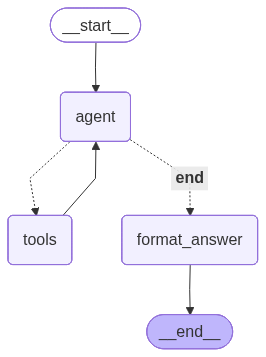

In [9]:
from IPython.display import Image, display

# mermaid.ink API가 가끔 5xx를 뱉어서 max_retries 살짝 올림.
# 그래도 실패하면 Mermaid 소스 텍스트로 fallback.
try:
    display(Image(graph.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))
except Exception as e:
    print(f"draw_mermaid_png 실패 ({type(e).__name__}); Mermaid 소스로 대체:\n")
    print(graph.get_graph().draw_mermaid())

## 테스트 헬퍼 — tool call trace + 최종 ReActAnswer 출력

In [10]:
from langchain_core.messages import AIMessage, ToolMessage


def run_question(q: str) -> dict:
    print(f"\n{'='*70}\nQ. {q}\n{'='*70}")
    state = graph.invoke({"messages": [HumanMessage(content=q)], "final_answer": None})

    print("\n[Tool Call Trace]")
    any_call = False
    for m in state["messages"]:
        if isinstance(m, AIMessage) and m.tool_calls:
            for tc in m.tool_calls:
                any_call = True
                args = str(tc["args"])
                if len(args) > 200: args = args[:200] + " …(truncated)"
                print(f"  → {tc['name']}({args})")
        elif isinstance(m, ToolMessage):
            content = m.content if len(m.content) <= 240 else m.content[:240] + " …(truncated)"
            print(f"  ← {m.name}: {content}")
    if not any_call: print("  (도구 호출 없음)")

    ans: ReActAnswer = state["final_answer"]
    print(f"\n[Final Answer]  used_tools={ans.used_tools}  sources={ans.sources}  confidence={ans.confidence}")
    print("-" * 70)
    print(ans.answer)
    return state

## 테스트 4개 — 개념 / 추천 / 풀이 리뷰 / 다단계

### Q1 개념

In [11]:
_ = run_question("이분 탐색 패턴 핵심 아이디어, 시간복잡도, 자주 하는 실수를 정리해 줘.")


Q. 이분 탐색 패턴 핵심 아이디어, 시간복잡도, 자주 하는 실수를 정리해 줘.



[Tool Call Trace]
  → get_algorithm_pattern({'pattern_name': 'binary-search'})
  ← get_algorithm_pattern: {"name_en": "Binary Search", "name_ko": "이분 탐색", "when_to_use": "정렬 배열에서 값 찾기, 또는 답이 단조성을 가지는 최적화 (parametric search).", "complexity": "O(log N)", "template": "def binary_search(arr, target):\n    lo, hi = 0, len(arr) - 1\n    while lo <= h …(truncated)

[Final Answer]  used_tools=['binary-search']  sources=['binary-search']  confidence=0.9
----------------------------------------------------------------------
이분 탐색(Binary Search)의 핵심 아이디어는 정렬된 배열에서 특정 값을 빠르게 찾거나, 답이 단조성을 가지는 최적화 문제(parametric search)에 활용하는 것입니다. 시간복잡도는 O(log N)으로 매우 효율적입니다. 자주 하는 실수로는 while 조건문에서 lo <= hi 와 lo < hi 를 혼동하는 점(lo <= hi가 닫힌 구간 탐색에 안전), parametric search 시 단조성 증명을 누락하는 점, 그리고 lower bound와 upper bound 개념이 모호할 때 bisect 모듈을 활용하지 않는 점이 있습니다. 기본적인 이분 탐색 템플릿은 다음과 같습니다:

def binary_search(arr, target):
    lo, hi = 0, len(arr) - 1
    while lo <= hi:
        mid = (lo + hi) // 2
        if arr[mid] == target

### Q2 추천

In [12]:
_ = run_question("프로그래머스에서 Lv.3 이면서 binary-search 토픽인 문제를 추천해 줘.")


Q. 프로그래머스에서 Lv.3 이면서 binary-search 토픽인 문제를 추천해 줘.



[Tool Call Trace]
  → recommend_problems({'topic': 'binary-search', 'level': 'Lv.3'})
  ← recommend_problems: [{"id": "pgs-43238", "title": "입국심사", "level": "Lv.3", "topics": ["binary-search"], "url": "https://school.programmers.co.kr/learn/courses/30/lessons/43238", "description": "n명과 각 입국 심사대 처리 시간 times[]가 주어질 때, 모두 심사하기 위한 최소 시간을 구하는 문제. 답이 시간 …(truncated)

[Final Answer]  used_tools=['recommend_problems']  sources=['pgs-43238', 'binary-search']  confidence=0.9
----------------------------------------------------------------------
프로그래머스에서 Lv.3 이면서 binary-search 토픽인 문제로 "입국심사" 문제를 추천합니다. 문제 링크는 https://school.programmers.co.kr/learn/courses/30/lessons/43238 이며, n명과 각 입국 심사대 처리 시간 times[]가 주어질 때 모두 심사하기 위한 최소 시간을 구하는 문제입니다. 이 문제는 답이 시간 t에 대해 단조이므로 parametric binary search 기법을 활용하는 문제입니다.


### Q3 풀이 리뷰 (TLE 나는 brute-force 코드)

In [13]:
q = """
프로그래머스 \"입국심사\" (pgs-43238) 풀이를 리뷰해줘. 시간 초과가 나는데 왜인지, 어떻게 고쳐야 하는지 알려줘.

내 코드:
```python
def solution(n, times):
    t = 0
    while True:
        t += 1
        capacity = 0
        for x in times:
            capacity += t // x
        if capacity >= n:
            return t
```
"""
_ = run_question(q)


Q. 
프로그래머스 "입국심사" (pgs-43238) 풀이를 리뷰해줘. 시간 초과가 나는데 왜인지, 어떻게 고쳐야 하는지 알려줘.

내 코드:
```python
def solution(n, times):
    t = 0
    while True:
        t += 1
        capacity = 0
        for x in times:
            capacity += t // x
        if capacity >= n:
            return t
```




[Tool Call Trace]
  → review_solution({'problem_id': 'pgs-43238', 'user_code': 'def solution(n, times):\n    t = 0\n    while True:\n        t += 1\n        capacity = 0\n        for x in times:\n            capacity += t // x\n        if …(truncated))
  ← review_solution: {"problem_id": "pgs-43238", "title": "입국심사", "level": "Lv.3", "topics": ["binary-search"], "reference_approach": "f(t) = sum(t // x for x in times)는 t에 대해 단조 증가. f(t) >= n 인 최소 t를 이분 탐색.", "reference_complexity": "O(M log(max(times) * n)),  …(truncated)

[Final Answer]  used_tools=['pgs-43238']  sources=['pgs-43238', 'binary-search']  confidence=0.9
----------------------------------------------------------------------
현재 코드는 t를 1부터 1씩 증가시키면서 처리 가능한 사람 수를 계산하는 선형 탐색 방식이라, n과 times가 클 경우 t가 매우 커져 시간 초과가 발생합니다. 문제의 핵심은 f(t) = sum(t // x for x in times)가 t에 대해 단조 증가한다는 점입니다. 이를 이용해 이분 탐색으로 최소 t를 빠르게 찾을 수 있습니다. 개선 방법은 t의 범위를 1부터 max(times) * n까지 잡고, 중간값 mid에서 처리 가능한 사람 수를 계산해 f(mid) >= n이면 hi를 mid-1로 줄이고, 그렇지 않으면 lo를 mi

### Q4 다단계 (패턴 + 추천 병렬 호출)

In [14]:
_ = run_question(
    "슬라이딩 윈도우 패턴이 뭔지 핵심만 설명해 주고, "
    "프로그래머스 Lv.3 sliding-window 문제도 한 개 추천해 줘."
)


Q. 슬라이딩 윈도우 패턴이 뭔지 핵심만 설명해 주고, 프로그래머스 Lv.3 sliding-window 문제도 한 개 추천해 줘.



[Tool Call Trace]
  → get_algorithm_pattern({'pattern_name': 'sliding-window'})
  → recommend_problems({'topic': 'sliding-window', 'level': 'Lv.3'})
  ← get_algorithm_pattern: {"name_en": "Sliding Window", "name_ko": "슬라이딩 윈도우", "when_to_use": "연속 부분배열/문자열의 통계. 가변 크기는 'longest/shortest with X' 패턴.", "complexity": "O(N)", "template": "def longest_unique_substring(s):\n    seen = {}\n    left = best = 0\n    for ri …(truncated)
  ← recommend_problems: [{"id": "pgs-67258", "title": "보석 쇼핑", "level": "Lv.3", "topics": ["sliding-window", "hash-map"], "url": "https://school.programmers.co.kr/learn/courses/30/lessons/67258", "description": "모든 종류의 보석을 포함하는 가장 짧은 연속 구간. 가변 슬라이딩 윈도우."}]

[Final Answer]  used_tools=['functions.get_algorithm_pattern', 'functions.recommend_problems']  sources=['pgs-67258', 'sliding-window']  confidence=0.95
----------------------------------------------------------------------
슬라이딩 윈도우 패턴은 연속된 부분 배열이나 문자열에서 특정 조건을 만족하는 구간을 찾을 때 사용하며, 좌우 포인터로 윈도우 크기를 조절해 O(N) 시간복잡